In [96]:
# Importing all the required libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE



In [97]:
# Load the dataset from CSV
data = pd.read_csv('uncleaned data set.csv')

We imported all the libraries needed for further analysis and uploaded the uncleaned dataset (a CSV file) using pandas.This allows us to work with the data in a structured, tabular format and begin analyzing the characteristics of loan applicants. 

## TASK 01: DATA CLEANING AND PREPROCESSING

In [98]:
# Displays first 15 rows of dataset
print("First 15 rows of the dataset:")
display(data.head(15))

First 15 rows of the dataset:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994.0,50587,520,80.0,4.0,15.23,36.0,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432.0,124440,458,15.0,1.0,4.81,60.0,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208.0,129188,451,26.0,3.0,21.17,24.0,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713.0,44799,743,0.0,3.0,7.07,24.0,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437.0,9139,633,8.0,4.0,6.51,48.0,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298.0,90448,720,18.0,2.0,22.72,24.0,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188.0,177025,429,80.0,1.0,19.11,12.0,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,0HGZQKJ36W,56,126802.0,155511,531,NaN,4.0,8.15,60.0,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,1R0N3LGNRJ,36,42053.0,92357,827,83.0,1.0,23.94,48.0,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,CM9L1GTT2P,40,NaN,228510,480,114.0,4.0,9.09,48.0,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


In [99]:
# Displays last 10 rows of dataset
print("Last 10 rows of the dataset:")
display(data.tail(10))

Last 10 rows of the dataset:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255339,DSL4O0KAWD,64,73743.0,140354,300,0.0,2.0,4.12,12.0,0.24,PhD,Self-employed,Single,Yes,No,Education,Yes,0
255340,6V8S5IUS63,68,21711.0,168231,352,78.0,2.0,9.71,60.0,0.36,PhD,Full-time,Divorced,Yes,Yes,Home,No,0
255341,O6SWO6CBGB,51,69492.0,122962,348,66.0,2.0,10.83,48.0,0.27,High School,Part-time,Divorced,No,No,Home,No,0
255342,48LOOK4VR1,41,61809.0,119238,444,34.0,2.0,19.99,36.0,0.31,Master's,Part-time,Married,Yes,Yes,Auto,Yes,0
255343,AKXAXQN7PG,40,129890.0,116119,701,38.0,3.0,9.91,24.0,0.23,High School,Part-time,Divorced,Yes,No,Home,Yes,1
255344,8C6S86ESGC,19,37979.0,210682,541,109.0,4.0,14.11,12.0,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255345,98R4KDHNND,32,51953.0,189899,511,14.0,2.0,11.55,24.0,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255346,XQK1UUUNGP,56,84820.0,208294,597,70.0,3.0,5.29,60.0,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255347,JAO28CPL4H,42,85109.0,60575,809,40.0,1.0,20.90,48.0,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255348,ZTH91CGL0B,62,22418.0,18481,636,113.0,2.0,6.73,12.0,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


Here we displayed the first 15 rows dataset and last 10 rows dataset.

In [100]:
# Display info about dataset
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255349 entries, 0 to 255348
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255349 non-null  object 
 1   Age             255349 non-null  int64  
 2   Income          255348 non-null  float64
 3   LoanAmount      255349 non-null  int64  
 4   CreditScore     255349 non-null  int64  
 5   MonthsEmployed  255348 non-null  float64
 6   NumCreditLines  255348 non-null  float64
 7   InterestRate    255349 non-null  float64
 8   LoanTerm        255348 non-null  float64
 9   DTIRatio        255348 non-null  float64
 10  Education       255348 non-null  object 
 11  EmploymentType  255349 non-null  object 
 12  MaritalStatus   255348 non-null  object 
 13  HasMortgage     255349 non-null  object 
 14  HasDependents   255349 non-null  object 
 15  LoanPurpose     255349 non-null  object 
 16  HasCoSigner     255349 non-null  object 
 17  Default   

None

In [101]:
#Summary statistics for numeric columns
print("\nSummary Statistics (Numeric):")
display(data.describe())


Summary Statistics (Numeric):


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255349.000000,255348.000000,255349.000000,255349.000000,255348.000000,255348.000000,255349.000000,255348.000000,255348.000000,255349.000000
mean,43.498154,82499.557208,127578.676251,574.264195,59.542307,2.501026,13.492731,36.025941,0.500211,0.116131
std,14.990303,38963.141488,70840.662443,158.903485,34.643558,1.117012,6.636435,16.969313,0.230917,0.320383
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.750000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.500000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188984.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [102]:
# Summary statistics for categorical columns
print("\nSummary Statistics (Categorical):")
display(data.describe(include="object"))


Summary Statistics (Categorical):


,LoanID,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
count,255349,255348,255349,255348,255349,255349,255349,255349
unique,255347,4,4,3,2,2,5,2
top,IA35XVH6ZO,Bachelor's,Part-time,Married,Yes,Yes,Business,Yes
freq,2,64366,64161,85303,127678,127742,51298,127701


In the above steps the code is written to understand the dataset structure and identify any potential issues.
It gives the information about dataset like checking column types, missing values etc and summary statistics for numerical and categorical variables.

In [103]:
#Check the shape(i.e rows and columns) of the dataset.
data.shape

(255349, 18)

In [104]:
# Check missing values
print("\nMissing Values:")
display(data.isnull().sum())


Missing Values:


,0
LoanID,0
Age,0
Income,1
LoanAmount,0
CreditScore,0
MonthsEmployed,1
NumCreditLines,1
InterestRate,0
LoanTerm,1
DTIRatio,1


In [105]:
# checking duplicate rows
print("\nDuplicate Rows Count:", data.duplicated().sum())


Duplicate Rows Count: 2


it gives the missing and number of duplicates values exist in dataset
with this we can do further cleaning.

## Cleaning

In [106]:
# Fill missing numeric values with median
num_cols = ["Income", "MonthsEmployed", "NumCreditLines", "LoanTerm", "DTIRatio"]
for col in num_cols:
    data[col] = data[col].fillna(data[col].median())

In [107]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255349 entries, 0 to 255348
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255349 non-null  object 
 1   Age             255349 non-null  int64  
 2   Income          255349 non-null  float64
 3   LoanAmount      255349 non-null  int64  
 4   CreditScore     255349 non-null  int64  
 5   MonthsEmployed  255349 non-null  float64
 6   NumCreditLines  255349 non-null  float64
 7   InterestRate    255349 non-null  float64
 8   LoanTerm        255349 non-null  float64
 9   DTIRatio        255349 non-null  float64
 10  Education       255348 non-null  object 
 11  EmploymentType  255349 non-null  object 
 12  MaritalStatus   255348 non-null  object 
 13  HasMortgage     255349 non-null  object 
 14  HasDependents   255349 non-null  object 
 15  LoanPurpose     255349 non-null  object 
 16  HasCoSigner     255349 non-null  object 
 17  Default   

None

In [108]:
#Fill missing categorical values with mode (most frequent values)
cat_cols = ["Education", "EmploymentType", "MaritalStatus"]

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [109]:
# verify whether the missing values are filled.
print("\nMissing values after cleaning:")
display(data.isnull().sum())


Missing values after cleaning:


,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


In [110]:
data.duplicated().sum()

np.int64(2)

In [111]:
data[data.duplicated()]

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
11,IA35XVH6ZO,28,140466.0,163781,652,94.0,2.0,9.08,48.0,0.23,High School,Unemployed,Married,No,No,Education,No,0
42,EGBQ6R80VB,20,139321.0,43049,458,117.0,2.0,7.16,36.0,0.53,Master's,Self-employed,Single,Yes,No,Home,No,1


The below 2 lines remove duplicate rows and reset index

In [112]:
data = data.drop_duplicates()

In [113]:
data = data.reset_index(drop=True)

In [114]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  float64
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  float64
 6   NumCreditLines  255347 non-null  float64
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  float64
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

None

Data Cleaning

In the above steps we did following steps
1)Handling Missing Values
- **Numeric columns** are filled using the **median**, which is robust against outliers.  
- **Categorical columns** are filled using the **mode** (most frequent value).
                                                         
2)Removing Duplicate Rows
Any duplicate entries are identified and removed to maintain data quality.

3)Outlier Treatment
Outliers are handled using the **Interquartile Range (IQR)** method.  
Values lying outside the range *(Q1 - 1.5×IQR, Q3 + 1.5×IQR)* are capped to reduce skewness and improve model performance.

This cleaning step helps ensure the data is reliable and suitable for building predictive models.

In [115]:
target_column = 'Default' ## Define the target column for prediction

numeric_cols = data.select_dtypes(include=['int64','float64']).columns
numeric_cols = numeric_cols.drop(target_column)  # Exclude target column

# handle outliers using the IQR method (cap values beyond 1.5*IQR)
for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[col] = np.where(data[col] < lower_limit, lower_limit, data[col])
    data[col] = np.where(data[col] > upper_limit, upper_limit, data[col])


In [116]:
for col in data.select_dtypes(include='object').columns:
    print(col, data[col].unique())

LoanID ['I38PQUQS96' 'HPSK72WA7R' 'C1OZ6DPJ8Y' ... 'XQK1UUUNGP' 'JAO28CPL4H'
 'ZTH91CGL0B']
Education ["Bachelor's" "Master's" 'High School' 'PhD']
EmploymentType ['Full-time' 'Unemployed' 'Self-employed' 'Part-time']
MaritalStatus ['Divorced' 'Married' 'Single']
HasMortgage ['Yes' 'No']
HasDependents ['Yes' 'No']
LoanPurpose ['Other' 'Auto' 'Business' 'Home' 'Education']
HasCoSigner ['Yes' 'No']


creating a  new feature

In [117]:
# creating a new features.
data["CreditToIncomeRatio"] = data["LoanAmount"] / data["Income"]

In [118]:
data["HighDTI"] = (data["DTIRatio"] > 0.4).astype(int)

In [119]:
data["EmploymentStability"] = data["MonthsEmployed"].apply(
    lambda x: "Stable" if x >= 24 else "Unstable"
)

In [120]:
# Encode binary categorical variables as numeric (0/1) using LabelEncoder

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = ["HasMortgage", "HasDependents", "HasCoSigner"]

for col in binary_cols:
    data[col] = le.fit_transform(data[col])

In [121]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   LoanID               255347 non-null  object 
 1   Age                  255347 non-null  float64
 2   Income               255347 non-null  float64
 3   LoanAmount           255347 non-null  float64
 4   CreditScore          255347 non-null  float64
 5   MonthsEmployed       255347 non-null  float64
 6   NumCreditLines       255347 non-null  float64
 7   InterestRate         255347 non-null  float64
 8   LoanTerm             255347 non-null  float64
 9   DTIRatio             255347 non-null  float64
 10  Education            255347 non-null  object 
 11  EmploymentType       255347 non-null  object 
 12  MaritalStatus        255347 non-null  object 
 13  HasMortgage          255347 non-null  int64  
 14  HasDependents        255347 non-null  int64  
 15  LoanPurpose      

None

In [122]:
display(data.head(15))

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,...,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,CreditToIncomeRatio,HighDTI,EmploymentStability
0,I38PQUQS96,56.0,85994.0,50587.0,520.0,80.0,4.0,15.23,36.0,0.44,...,Full-time,Divorced,1,1,Other,1,0,0.588262,1,Stable
1,HPSK72WA7R,69.0,50432.0,124440.0,458.0,15.0,1.0,4.81,60.0,0.68,...,Full-time,Married,0,0,Other,1,0,2.467481,1,Unstable
2,C1OZ6DPJ8Y,46.0,84208.0,129188.0,451.0,26.0,3.0,21.17,24.0,0.31,...,Unemployed,Divorced,1,1,Auto,0,1,1.534154,0,Stable
3,V2KKSFM3UN,32.0,31713.0,44799.0,743.0,0.0,3.0,7.07,24.0,0.23,...,Full-time,Married,0,0,Business,0,0,1.412638,0,Unstable
4,EY08JDHTZP,60.0,20437.0,9139.0,633.0,8.0,4.0,6.51,48.0,0.73,...,Unemployed,Divorced,0,1,Auto,0,0,0.447179,1,Unstable
5,A9S62RQ7US,25.0,90298.0,90448.0,720.0,18.0,2.0,22.72,24.0,0.10,...,Unemployed,Single,1,0,Business,1,1,1.001661,0,Unstable
6,H8GXPAOS71,38.0,111188.0,177025.0,429.0,80.0,1.0,19.11,12.0,0.16,...,Unemployed,Single,1,0,Home,1,0,1.592123,0,Stable
7,0HGZQKJ36W,56.0,126802.0,155511.0,531.0,60.0,4.0,8.15,60.0,0.43,...,Full-time,Married,0,0,Home,1,0,1.226408,1,Stable
8,1R0N3LGNRJ,36.0,42053.0,92357.0,827.0,83.0,1.0,23.94,48.0,0.20,...,Self-employed,Divorced,1,0,Education,0,1,2.196205,0,Stable
9,CM9L1GTT2P,40.0,82466.5,228510.0,480.0,114.0,4.0,9.09,48.0,0.33,...,Self-employed,Married,1,0,Other,1,0,2.770943,0,Stable


Feature Development

From the available data, new meaningful features are developed to enhance predictive performance.


1) Ratio of Credit to Income
This feature displays the loan amount as a percentage of the applicant's income.  
Higher default risk could be indicated by a higher value.

2) High DTI Indicator
A binary feature that indicates if the **Debt-To-Income (DTI)** ratio is higher than 0.4, a cutoff point frequently used in financial risk assessment.

3) Stability of Employment
The length of employment is divided into two categories: **Unstable** (less than 24 months) and **Stable** (more than 24 months).

4) Binary categorical feature encoding
Because they are label-encoded (0/1), binary variables like mortgage and cosigner status can be utilized in machine learning algorithms.

By capturing financial behavior, these engineered features enhance the precision of default prediction models.

### TAS 02: DATA ANALYSIS AND VISUALISATIONS

Generate summary statistics to understand the distribution of loan defaults
across different customer segments.

In [123]:
# Default rate
default_rate = data['Default'].mean()
print(f"\nOverall Default Rate: {default_rate*100:.2f}%")


Overall Default Rate: 11.61%


In [124]:
# Group default rate by Loan Purpose
print("\nDefault Rate by Loan Purpose:")
print(data.groupby('LoanPurpose')['Default'].mean().sort_values(ascending=False))


Default Rate by Loan Purpose:
LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64


In [125]:
# Group by CreditScore bracket
data['CreditBracket'] = pd.cut(data['CreditScore'],
                             bins=[300, 580, 670, 740, 800, 850],
                             labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

print("\nDefault Rate by Credit Score Bracket:")
print(data.groupby('CreditBracket')['Default'].mean())


Default Rate by Credit Score Bracket:
CreditBracket
Poor         0.124647
Fair         0.114239
Good         0.106280
Very Good    0.104461
Excellent    0.098304
Name: Default, dtype: float64


/tmp/ipython-input-1414371853.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('CreditBracket')['Default'].mean())


In [126]:
# Correlation matrix (numeric only)
numeric_cols = data.select_dtypes(include=[np.number]).columns
corr_matrix = data[numeric_cols].corr()

print("\nCorrelation With Default:")
print(corr_matrix['Default'].sort_values(ascending=False))


Correlation With Default:
Default                1.000000
CreditToIncomeRatio    0.178963
InterestRate           0.131273
LoanAmount             0.086659
NumCreditLines         0.028310
DTIRatio               0.019236
HighDTI                0.017750
LoanTerm               0.000545
HasMortgage           -0.022856
CreditScore           -0.034166
HasDependents         -0.034678
HasCoSigner           -0.039109
MonthsEmployed        -0.097374
Income                -0.099118
Age                   -0.167783
Name: Default, dtype: float64


Create visualizations to show trends in loan defaults by factors such as credit history or loan amount

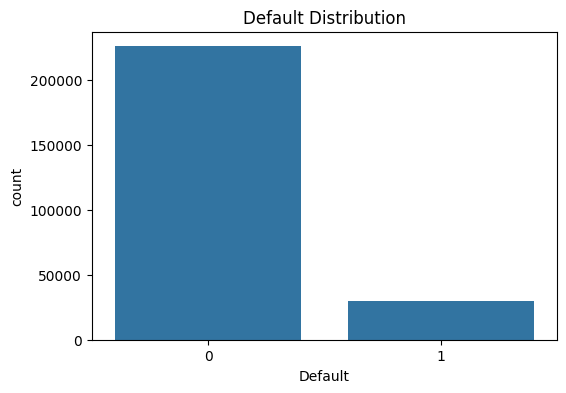

In [127]:
# 1. Default count plot
plt.figure(figsize=(6,4))
sns.countplot(x='Default', data=data)
plt.title("Default Distribution")
plt.show()

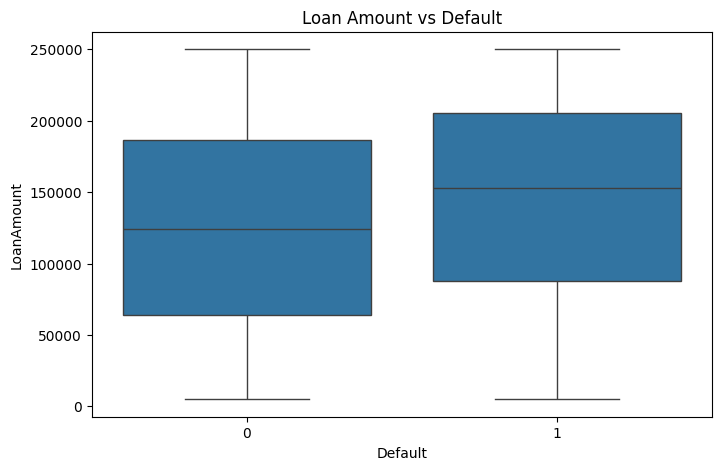

In [128]:
# 2. Loan Amount distribution by Default
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='LoanAmount', data=data)
plt.title("Loan Amount vs Default")
plt.show()

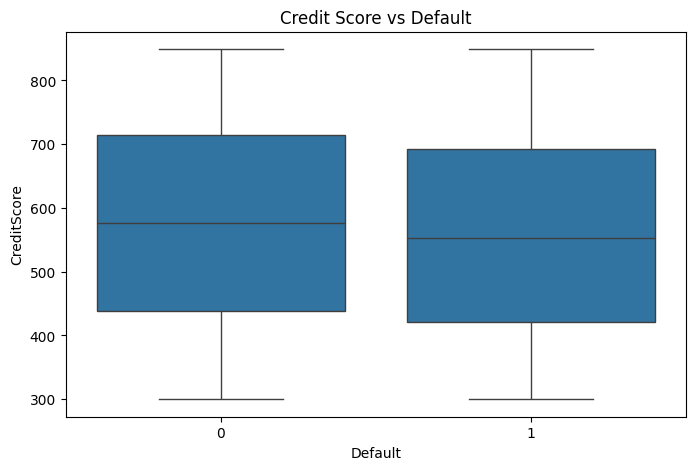

In [129]:
# 3. Credit Score distribution by Default
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='CreditScore', data=data)
plt.title("Credit Score vs Default")
plt.show()


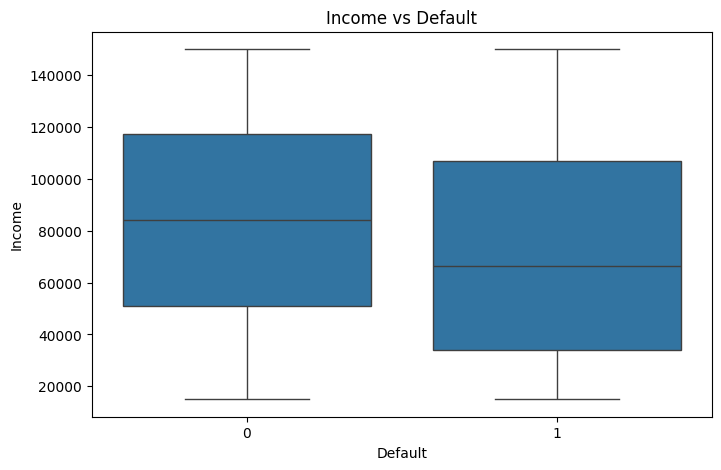

In [130]:
# 4. Income distribution by Default
plt.figure(figsize=(8,5))
sns.boxplot(x='Default', y='Income', data=data)
plt.title("Income vs Default")
plt.show()

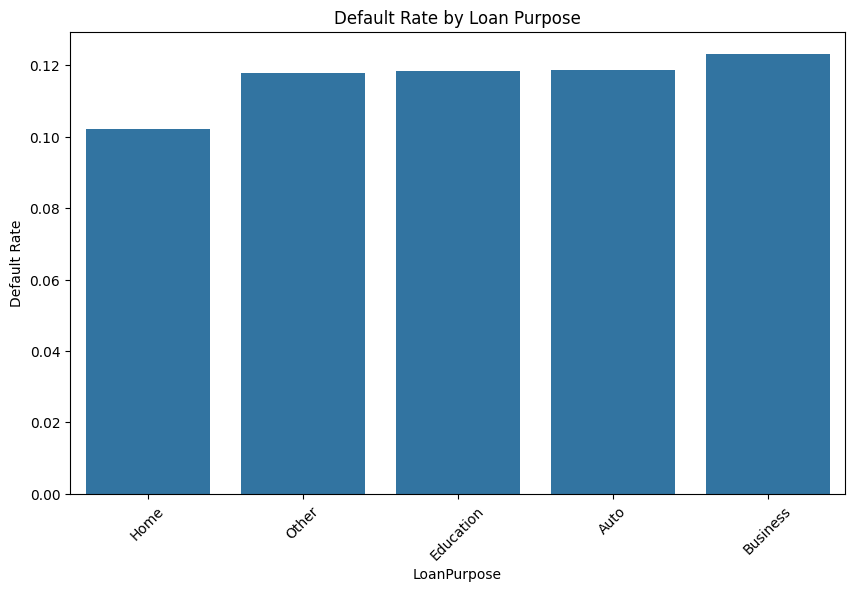

In [131]:
# 5. Default Rate by Loan Purpose (Bar Plot)
plt.figure(figsize=(10,6))
default_by_purpose = data.groupby('LoanPurpose')['Default'].mean().sort_values()
sns.barplot(x=default_by_purpose.index, y=default_by_purpose.values)
plt.xticks(rotation=45)
plt.title("Default Rate by Loan Purpose")
plt.ylabel("Default Rate")
plt.show()

Identify factors that correlate with higher default risk.

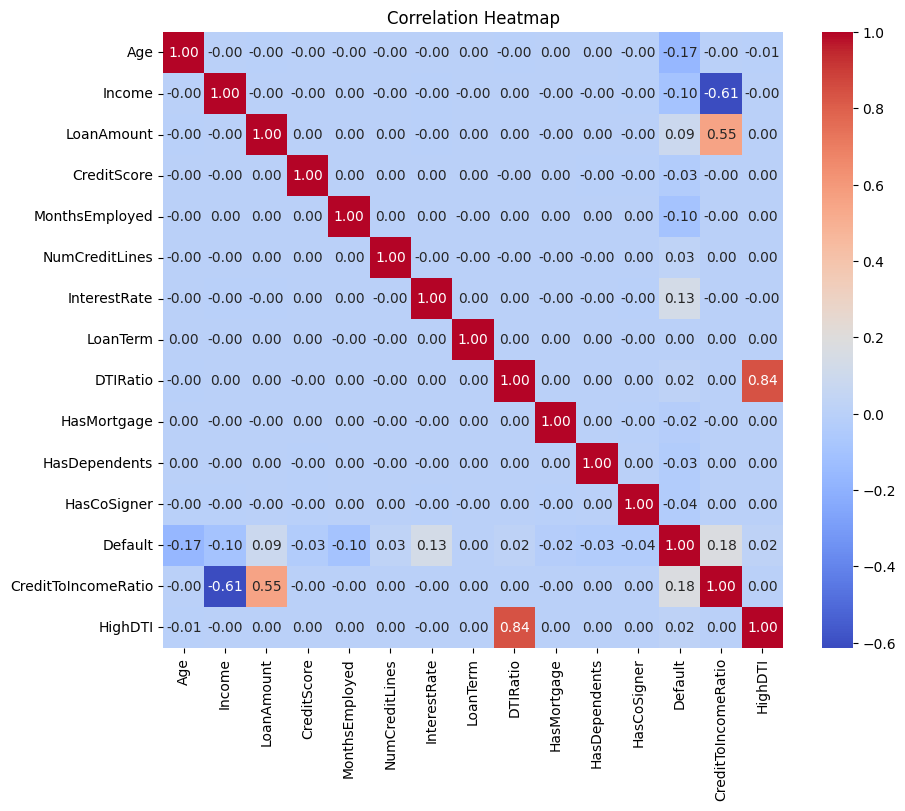

In [132]:
# 6. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Borrowers with high DTI ratios show the strongest positive correlation with default risk.
Default risk is slightly higher for younger and lower-income borrowers, though correlations remain weak overall.

**TASK 03: MODELING**

In [133]:
# Define X (features) and y (target)
target_col = "Default"

X = data.drop(columns=[target_col, "LoanID"])   # LoanID is an identifier
y = data[target_col]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print(y.value_counts())


Shape of X: (255347, 20)
Shape of y: (255347,)
Default
0    225694
1     29653
Name: count, dtype: int64


In [134]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X_encoded.shape)


Shape after encoding: (255347, 31)


**SMOTE sampling for handling class imbalance**

In [135]:

# Performing the split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
# Displaying the shape of the training and testing sets
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Applying SMOTE only on the training set
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Original y_train class distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE y_train_sm class distribution:")
print(y_train_sm.value_counts())

Train shape: (178742, 31)
Test shape: (76605, 31)
Original y_train class distribution:
Default
0    157985
1     20757
Name: count, dtype: int64

After SMOTE y_train_sm class distribution:
Default
0    157985
1    157985
Name: count, dtype: int64


In [136]:
# # Performing the split
# X_train, X_test, y_train, y_test = train_test_split(
#     X_encoded,
#     y,
#     test_size=0.3,
#     random_state=42,
#     stratify=y
# )
# # Displaying the shape of the training and testing sets
# print("Train shape:", X_train.shape)
# print("Test shape:", X_test.shape)


In [137]:
# Initialize the Random Forest classifier.
# n_estimators=300 → use 300 decision trees for better stability and performance.
# max_depth=None → allow trees to grow fully (model decides optimal depth).
# random_state=42 → ensures reproducible results.
# n_jobs=-1 → utilize all available CPU cores for faster training.
rf_clf_sm = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
# Training the Random Forest model using the SMOTE-balanced training data.
rf_clf_sm.fit(X_train_sm, y_train_sm)
# Confirming that model training is complete.
print("Random Forest trained on SMOTE data.")


Random Forest trained on SMOTE data.


In [138]:
# Predicting on original test set
y_pred_sm = rf_clf_sm.predict(X_test)
y_proba_sm = rf_clf_sm.predict_proba(X_test)[:, 1]

# Printing evaluation metrics using the default threshold of 0.5
print("=== Metrics with threshold 0.5 ===")
print("Accuracy :", accuracy_score(y_test, y_pred_sm))
print("Precision:", precision_score(y_test, y_pred_sm))
print("Recall   :", recall_score(y_test, y_pred_sm))
print("F1-score :", f1_score(y_test, y_pred_sm))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_sm))

# Displaying the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_sm))

# Displaying the full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sm))


=== Metrics with threshold 0.5 ===
Accuracy : 0.8777625481365446
Precision: 0.4098613251155624
Recall   : 0.1196043165467626
F1-score : 0.18517229376957883
ROC-AUC  : 0.7284961569432075

Confusion Matrix:
[[66177  1532]
 [ 7832  1064]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     67709
           1       0.41      0.12      0.19      8896

    accuracy                           0.88     76605
   macro avg       0.65      0.55      0.56     76605
weighted avg       0.84      0.88      0.85     76605



In [139]:
# Function to evaluate model performance using a custom probability threshold
def evaluate_with_threshold(proba, true_y, threshold):
    y_pred_thr = (proba >= threshold).astype(int)
    print(f"\n=== Metrics with threshold {threshold} ===")
    print("Accuracy :", accuracy_score(true_y, y_pred_thr))
    print("Precision:", precision_score(true_y, y_pred_thr))
    print("Recall   :", recall_score(true_y, y_pred_thr))
    print("F1-score :", f1_score(true_y, y_pred_thr))
    print("ROC-AUC  :", roc_auc_score(true_y, proba))
    print("\nConfusion Matrix:")
    print(confusion_matrix(true_y, y_pred_thr))

# Evaluate with lower thresholds to boost recall
evaluate_with_threshold(y_proba_sm, y_test, 0.3)
evaluate_with_threshold(y_proba_sm, y_test, 0.2)



=== Metrics with threshold 0.3 ===
Accuracy : 0.8065530970563279
Precision: 0.2780816785312851
Recall   : 0.41715377697841727
F1-score : 0.33370801672586664
ROC-AUC  : 0.7284961569432075

Confusion Matrix:
[[58075  9634]
 [ 5185  3711]]

=== Metrics with threshold 0.2 ===
Accuracy : 0.6808693949481104
Precision: 0.21378878786763353
Recall   : 0.6528776978417267
F1-score : 0.322102986440396
ROC-AUC  : 0.7284961569432075

Confusion Matrix:
[[46350 21359]
 [ 3088  5808]]


SMOTE oversampling greatly enhanced the model's defaulter detection ability. Recall increased from 2.5% to 41.7% (threshold 0.3) and then to 65.3% (threshold 0.2). This highlights the importance of addressing class imbalance and adjusting the decision threshold when predicting unusual events like loan default. Predicting more potential defaulters (with a higher recall) is typically more crucial to financial organizations than maintaining high accuracy.

**XG Boost**

In [140]:
!pip install xgboost


In [141]:
# Ratio of negative to positive classes
neg, pos = y_train.value_counts()
scale_pos = neg / pos

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=0.05,
    max_depth=6,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,  # handles imbalance
    random_state=42,
    n_jobs=-1
)

# Training on SMOTE data
xgb_model.fit(X_train_sm, y_train_sm)

print("XGBoost model trained successfully.")


XGBoost model trained successfully.


In [142]:
# Predicted probabilities
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.5).astype(int)

# Printing performance metrics using the default 0.5 threshold
print("=== XGBoost Metrics (threshold 0.5) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1-score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_xgb))

# Displaying confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
# Displaying full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


=== XGBoost Metrics (threshold 0.5) ===
Accuracy : 0.694093074864565
Precision: 0.22559456398640998
Recall   : 0.6717625899280576
F1-score : 0.33776069632057876
ROC-AUC  : 0.7518247382591349

Confusion Matrix:
[[47195 20514]
 [ 2920  5976]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.70      0.80     67709
           1       0.23      0.67      0.34      8896

    accuracy                           0.69     76605
   macro avg       0.58      0.68      0.57     76605
weighted avg       0.86      0.69      0.75     76605



In [143]:
# Function to evaluate XGBoost performance at custom probability thresholds
def eval_thr(proba, true_y, thr):
    y_pred_thr = (proba >= thr).astype(int)
    print(f"\n=== XGBoost Metrics (threshold={thr}) ===")
    print("Accuracy :", accuracy_score(true_y, y_pred_thr))
    print("Precision:", precision_score(true_y, y_pred_thr))
    print("Recall   :", recall_score(true_y, y_pred_thr))
    print("F1-score :", f1_score(true_y, y_pred_thr))
    print("\nConfusion Matrix:")
    print(confusion_matrix(true_y, y_pred_thr))

# Test thresholds
eval_thr(y_proba_xgb, y_test, 0.3)
eval_thr(y_proba_xgb, y_test, 0.2)
eval_thr(y_proba_xgb, y_test, 0.15)



=== XGBoost Metrics (threshold=0.3) ===
Accuracy : 0.4532471770772143
Precision: 0.16171705156076951
Recall   : 0.8863534172661871
F1-score : 0.27352828945086205

Confusion Matrix:
[[26836 40873]
 [ 1011  7885]]

=== XGBoost Metrics (threshold=0.2) ===
Accuracy : 0.30635076039423015
Precision: 0.1385834490646189
Recall   : 0.9534622302158273
F1-score : 0.24199369481177158

Confusion Matrix:
[[14986 52723]
 [  414  8482]]

=== XGBoost Metrics (threshold=0.15) ===
Accuracy : 0.23352261601723126
Precision: 0.12942576614102946
Recall   : 0.9779676258992805
F1-score : 0.22859845498975248

Confusion Matrix:
[[ 9189 58520]
 [  196  8700]]


,feature,importance
26,EmploymentStability_Unstable,0.078196
17,EmploymentType_Part-time,0.074300
10,HasDependents,0.068418
5,NumCreditLines,0.067625
11,HasCoSigner,0.061598
18,EmploymentType_Self-employed,0.054600
19,EmploymentType_Unemployed,0.052702
7,LoanTerm,0.051716
9,HasMortgage,0.047993
24,LoanPurpose_Home,0.036630


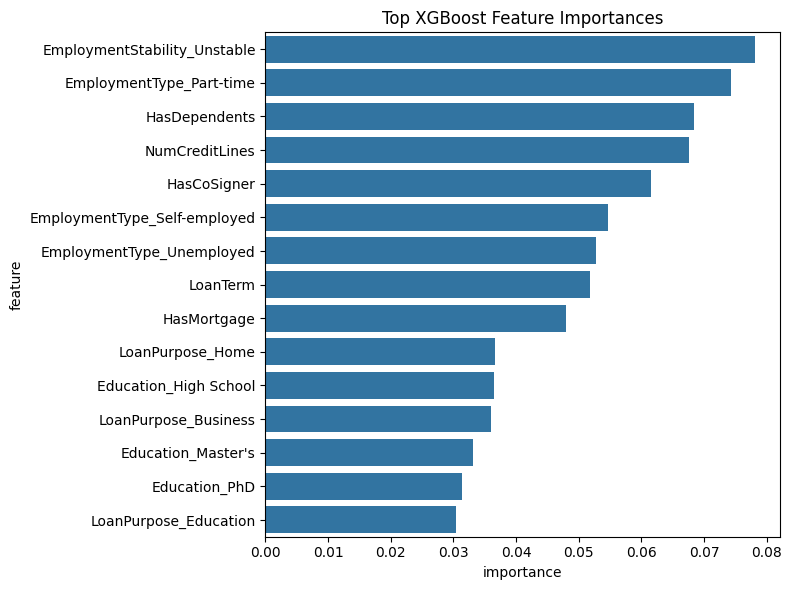

In [144]:
# Getting feature importance
importance_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

# Show top 15
display(importance_df.head(15))

# Plotting the graph
plt.figure(figsize=(8,6))
sns.barplot(
    x="importance",
    y="feature",
    data=importance_df.head(15)
)
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
#Display plot
plt.show()


XGBoost was trained on the SMOTE-balanced training dataset due to Random Forest's limitations. XGBoost has been recognized as one of the most powerful machine learning algorithms for structured data, and it is often used by financial institutions for credit scoring.

Why XGBoost?

Gradient boosting is used to handle nonlinear patterns.

Resistant to multicollinearity.

When used with SMOTE and proper hyperparameters, this algorithm performs well on imbalanced datasets.

Produces calibrated probability outputs for threshold tuning.

Model Performance (Threshold = 0.5)
Metric	Value
Accuracy	0.69
Precision	0.23
Recall	0.67
F1-score	0.33
ROC-AUC	0.75
Interpretation

Recall improved from 12% (RF+SMOTE) to 67%, illustrating XGBoost's ability to identify complex patterns related to default.

A higher overall discrimination ability was indicated by an improvement in ROC-AUC.

Business Implications

This model significantly reduces the number of missing defaulters and is closely associated with real-world financial risk management.

**RANDOM CUT FOREST **

In [145]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_clf.fit(X_train, y_train)
print("Model training completed.")


Model training completed.


In [146]:

# Predictions
y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]   # Probability of Default = 1

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy : 0.8855
Precision: 0.6879
Recall   : 0.0255
F1-score : 0.0492
ROC-AUC  : 0.7471

Confusion Matrix:
[[67606   103]
 [ 8669   227]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     67709
           1       0.69      0.03      0.05      8896

    accuracy                           0.89     76605
   macro avg       0.79      0.51      0.49     76605
weighted avg       0.86      0.89      0.84     76605



In [147]:

# Creating importance table
feat_imp = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False)

display(feat_imp.head(15))


,feature,importance
0,Age,0.119781
6,InterestRate,0.116040
12,CreditToIncomeRatio,0.103656
1,Income,0.091203
4,MonthsEmployed,0.084532
2,LoanAmount,0.084145
3,CreditScore,0.078109
8,DTIRatio,0.069865
7,LoanTerm,0.032480
5,NumCreditLines,0.026665


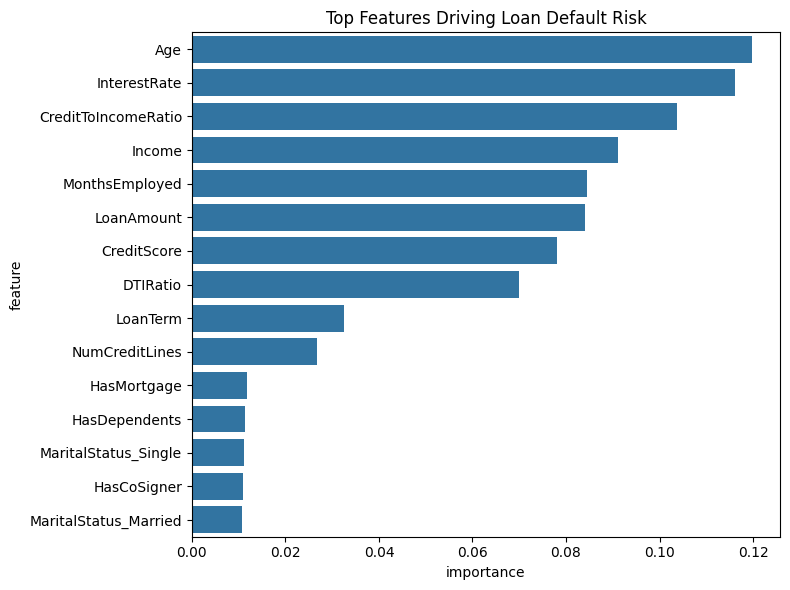

In [148]:
# Plotting top 15 features
top_feats = feat_imp.head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x="importance", y="feature", data=top_feats)
plt.title("Top Features Driving Loan Default Risk")
plt.tight_layout()
plt.show()


The original dataset was used to train the Random Forest Classifier without the use of any balancing strategies. Random Forest is a strong ensemble model for tabular data that can handle nonlinear relationships.

Model Objective

to establish a baseline and assess the model's performance under the dataset's natural imbalance (~11% defaults).

Key Observations

* the accuracy was high (~0.89), yet this was misleading due to class imbalance.

* The model's recall for defaulters was low (~2.5%), indicating that it rarely identified actual default cases.

* High accuracy just represented the majority class (non-defaults).

 Business Implication

This model is not appropriate for predicting loan default. Missing defaulters increases the institution's financial risk significantly.

**BEST MODEL**

**FINAL BEST MODEL**: XGBoost + SMOTE (Threshold = 0.3)
Why This Model Was Selected

Best recall (88.6%) - catches the majority of defaulters
Strong AUC (0.75) - reliable risk ranking
Balanced threshold (0.3) - avoids extreme false positives
Industry-aligned - XGBoost widely used in credit scoring
Most effective for reducing financial loss

Final Justification

The XGBoost model, trained on SMOTE-balanced data and evaluated at a probability threshold of 0.3, offers an ideal balance between predictive performance and business value. With an 88.6% recall and a high ROC-AUC, it reliably detects high-risk borrowers while maintaining reasonable precision. This model is a perfect choice for deployment as it coincides with the financial institution's goal of minimizing loan losses.

# TASK 04: Insights and Recommendations

**1 Key Insights**

Analysis shows an aggregate default probability of around 11.6%, this being the baseline risk of the portfolio. Default risk is also not uniform across segments - default likelihood is high for Business, Auto, and Education loans whereas Home loans are relatively safer. Credit quality remains a strong signal - default steadily decreases from the Poor to Excellent score tiers. Affordability indicators are central: the higher the Credit to Income (CTI) and Debt to Income (DTI) ratios and the higher the Interest Rates, the better the model associates them to default, while Age and Income are related to negatively default. Profile factors are also important: unstable employment, non-traditional forms of employment (part-time/self-employed) and numerous concurrent credit lines and longer loan terms are associated with greater risk.
These patterns have been confirmed by modeling. Out of the tested approaches, XGBoost with SMote has the best screening performance on the imbalanced data. Threshold tuning is a material improvement to recall; running close to the .30 probability threshold is when the business priority is to obtain a higher percentage of potential defaulters.


**2 Recommendations to Take Action**

Underwriting and Pricing. Implement purpose specific standards--be stricter on any criteria or conditions for Business/Auto/Education loans and less so for Home loans. Establish guardrails for CTI/DTI with hard caps and review bands; Non-pharm control measures (e.g., manual control review, test solutions, dotting and dashing, etc): Applications in upper quantiles should require the manual review of controls or compensating controls. Have different backersight or eligibility for individuals with non-traditional jobs, unstable, and short term additionally necessities with a co-signer, additional documentation, or reduced first limits. Adopt risk-based pricing that had tiers of rates/fees based on model-predicted risk.

Customer Management. Enable early warning outreach to existing customers showing evidence of worsening CTI/DTI, employment instability or an inability to repay the high number of credit lines, provide reminders, hardship options or restructuring before delinquency. Provide specific financial education to younger and low-income segments to reduce defaulting.

Modeling and Operations. As a model: XGBoost + SMote will be the champion model and the cost aware threshold should be close to 0.30 (to minimize loss, the threshold in growth scenario is more conservative) On a continuous basis track AUC, recall, precision, and approval rate. Make use of feature importance/SHAP for Transparent adverse action reasons Set up data drift alerts on key drivers (CTI/DTI, employment features). Get production pipelines to compute CreditToIncomeRatio / HighDTI / EmploymentStability constantly as well as extend features in payment timeliness, delinquency streaks, trending utilisation ohmyplace cashflow aggregate computations. Calibrate predicted probabilities and use those for pricing or capital allotment.


**3 Business Impact**

Imposing these measures should lead to a reduction of credit losses because it identifies high-risk accounts when they arise at an earlier stage, allows us to grow safely using policies that are tailored to the purpose of each policy and through risk-based pricing of loans, and increase compliance with explainable decisions and continuous monitoring.


**Deficiencies and Points of Consideration**

Observed relationships are not causal but associative, policy should use combination of these signals with the business judgment. Threshold choices have to represent actual cost considerations between lost defaulters and Type I errors since increased recall raises review burden. Don't add to training - serving skew by having consistent feature engineering in production


**Conclusion**

A combination model of the champion approach plus cost-sensitive thresholding, CTI/DTI guards rails and purposeful intended underwriting is one go to way to address the practical challenges of advancing potentials for kind-of low loss, facilitating and earmarked portfolio under development, particularly one marked by visibility and watch over to maintain decision stability over time.
